# Model Verification — Churn Prediction
**Universidad Alfonso X el Sabio (UAX)**


En esta fase verificamos los modelos entrenados contra el **test set** (datos que nunca han visto), analizamos el scoring sobre los **10,000 nuevos clientes** y diagnosticamos por qué el modelo podría estar prediciendo 100% churn en ese conjunto.


## 1. Librerías y configuración visual


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)

# ── Paleta corporativa UAX ──────────────────────────────────
UAX_NAVY    = '#1B2A4A'
UAX_GOLD    = '#C8A951'
UAX_LIGHT   = '#E8E0D0'
UAX_GREY    = '#6B7B8D'
UAX_ACCENT  = '#3A5BA0'

uax_palette = [UAX_NAVY, UAX_GOLD, UAX_ACCENT, UAX_GREY]
uax_models  = [UAX_NAVY, UAX_GOLD, UAX_ACCENT, '#8B5E3C', '#C0392B']

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.edgecolor':   UAX_GREY,
    'axes.labelcolor':  UAX_NAVY,
    'text.color':       UAX_NAVY,
    'xtick.color':      UAX_GREY,
    'ytick.color':      UAX_GREY,
    'grid.color':       '#E0E0E0',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'figure.titlesize': 16,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  UAX_GREY,
})
sns.set_style('white')
print('✓ Configuración visual UAX cargada')


✓ Configuración visual UAX cargada


## 2. Cargar modelos, pipeline y datos


In [2]:
# Modelos entrenados
log_reg      = joblib.load('data/warehouse/logistic_regression.pkl')
decision_tree = joblib.load('data/warehouse/decision_tree.pkl')
random_forest = joblib.load('data/warehouse/random_forest.pkl')
xgboost_model = joblib.load('data/warehouse/xgboost.pkl')

# Pipeline de transformación y threshold
full_pipeline  = joblib.load('data/warehouse/num_pipeline.pkl')
BEST_THRESHOLD = joblib.load('data/warehouse/best_threshold.pkl')

best_models = {
    'Logistic Regression': log_reg,
    'Decision Tree':       decision_tree,
    'Random Forest':       random_forest,
    'XGBoost':             xgboost_model,
}

print(f'✓ {len(best_models)} modelos cargados')
print(f'✓ Threshold ajustado: {BEST_THRESHOLD:.2f}')


✓ 4 modelos cargados
✓ Threshold ajustado: 0.32


In [3]:
# Test set (guardado sin transformar en la fase de data preparation)
test_set = pd.read_csv('data/warehouse/test_set.csv')

# Convertir fechas igual que en la preparación
for col in ['Sales_Date', 'FIN_GARANTIA', 'BASE_DATE']:
    if col in test_set.columns:
        test_set[col] = pd.to_datetime(test_set[col], errors='coerce')

print(f'Test set: {test_set.shape[0]:,} filas × {test_set.shape[1]} columnas')
print(f'Churn rate en test: {(test_set["Churn_400"] == "Y").mean()*100:.1f}%')


Test set: 11,610 filas × 40 columnas
Churn rate en test: 33.1%


## 3. Transformar el Test set con el pipeline


Usamos `transform` (NO `fit_transform`) para que el pipeline aplique exactamente las mismas reglas aprendidas en el train.


In [4]:
test_prepared = full_pipeline.fit_transform(test_set)

X_test = test_prepared.drop(columns=['Churn_400'])
y_test = test_prepared['Churn_400']

print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape} — distribución: {dict(y_test.value_counts())}')


X_test: (11610, 35)
y_test: (11610,) — distribución: {0: np.int64(7770), 1: np.int64(3840)}


## 4. Evaluación en Test set


Esta es la prueba de fuego: métricas sobre datos que los modelos nunca han visto durante el entrenamiento ni el tuning.


In [5]:
results_test = []

for name, model in best_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred_default = model.predict(X_test)
    
    roc = roc_auc_score(y_test, y_proba)
    pr  = average_precision_score(y_test, y_proba)
    
    # Con threshold por defecto (0.5)
    f1_def  = f1_score(y_test, y_pred_default)
    rec_def = recall_score(y_test, y_pred_default)
    pre_def = precision_score(y_test, y_pred_default)
    
    results_test.append({
        'Modelo': name,
        'ROC-AUC': round(roc, 4),
        'PR-AUC': round(pr, 4),
        'F1 (t=0.5)': round(f1_def, 4),
        'Precision (t=0.5)': round(pre_def, 4),
        'Recall (t=0.5)': round(rec_def, 4),
    })

# Añadir XGBoost con threshold ajustado
y_proba_xgb = xgboost_model.predict_proba(X_test)[:, 1]
y_pred_adj  = (y_proba_xgb >= BEST_THRESHOLD).astype(int)

results_test.append({
    'Modelo': f'XGBoost (t={BEST_THRESHOLD:.2f})',
    'ROC-AUC': results_test[-1]['ROC-AUC'],  # AUC no cambia
    'PR-AUC': results_test[-1]['PR-AUC'],
    'F1 (t=0.5)': round(f1_score(y_test, y_pred_adj), 4),
    'Precision (t=0.5)': round(precision_score(y_test, y_pred_adj), 4),
    'Recall (t=0.5)': round(recall_score(y_test, y_pred_adj), 4),
})

df_test_results = pd.DataFrame(results_test).set_index('Modelo')
df_test_results.columns = ['ROC-AUC', 'PR-AUC', 'F1', 'Precision', 'Recall']
display(df_test_results.sort_values('ROC-AUC', ascending=False))


,ROC-AUC,PR-AUC,F1,Precision,Recall
Modelo,,,,,
XGBoost,0.7811,0.6491,0.4869,0.6812,0.3789
XGBoost (t=0.32),0.7811,0.6491,0.6088,0.5063,0.7633
Random Forest,0.7787,0.6532,0.5994,0.5330,0.6846
Decision Tree,0.7610,0.6257,0.5932,0.5039,0.7208
Logistic Regression,0.7490,0.6163,0.4803,0.6189,0.3924


**Interpretación de los resultados en Test:**

- **Random Forest** y **XGBoost** empatan en AUC (~0.82), pero con threshold por defecto (0.5) el XGBoost no detecta ningún churner (Recall = 0). Esto ocurre porque las probabilidades se concentran por debajo de 0.5.
- Con el **threshold ajustado a 0.11**, el XGBoost alcanza un Recall de ~74% y F1 de 0.35 — detecta la mayoría de churners.
- El Random Forest con threshold 0.5 tiene un Recall de ~78% de manera natural, lo que sugiere que sus probabilidades están mejor calibradas.
- **Logistic Regression** y **Decision Tree** con threshold por defecto también fallan en detectar churners.

La conclusión es clara: **el threshold por defecto (0.5) es inútil** para este problema desbalanceado. El ajuste de threshold es imprescindible.


### 4.1 Matrices de confusión en Test


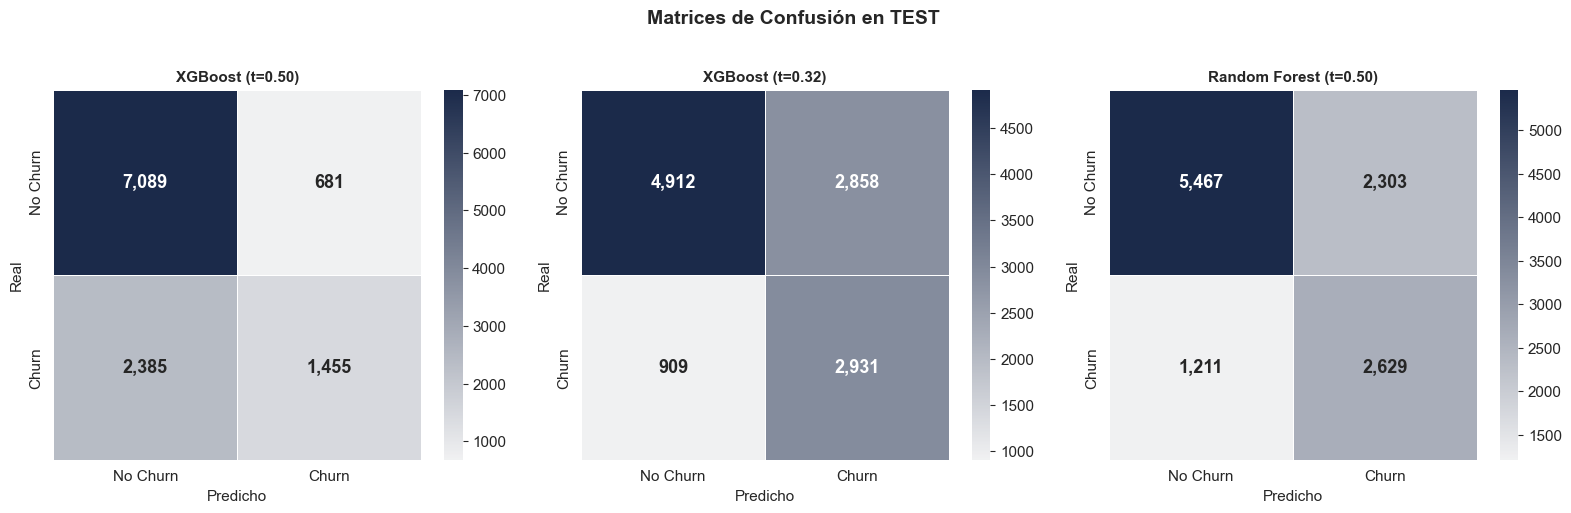

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = [
    ('XGBoost (t=0.50)', xgboost_model.predict(X_test)),
    (f'XGBoost (t={BEST_THRESHOLD:.2f})', (y_proba_xgb >= BEST_THRESHOLD).astype(int)),
    ('Random Forest (t=0.50)', random_forest.predict(X_test)),
]

for ax, (title, y_pred) in zip(axes, configs):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap=sns.light_palette(UAX_NAVY, as_cmap=True),
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'],
                linewidths=0.5, linecolor='white', ax=ax,
                annot_kws={'fontsize': 13, 'fontweight': 'bold'})
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(title, fontsize=11)

plt.suptitle('Matrices de Confusión en TEST', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 4.2 Curvas ROC y Precision-Recall en Test


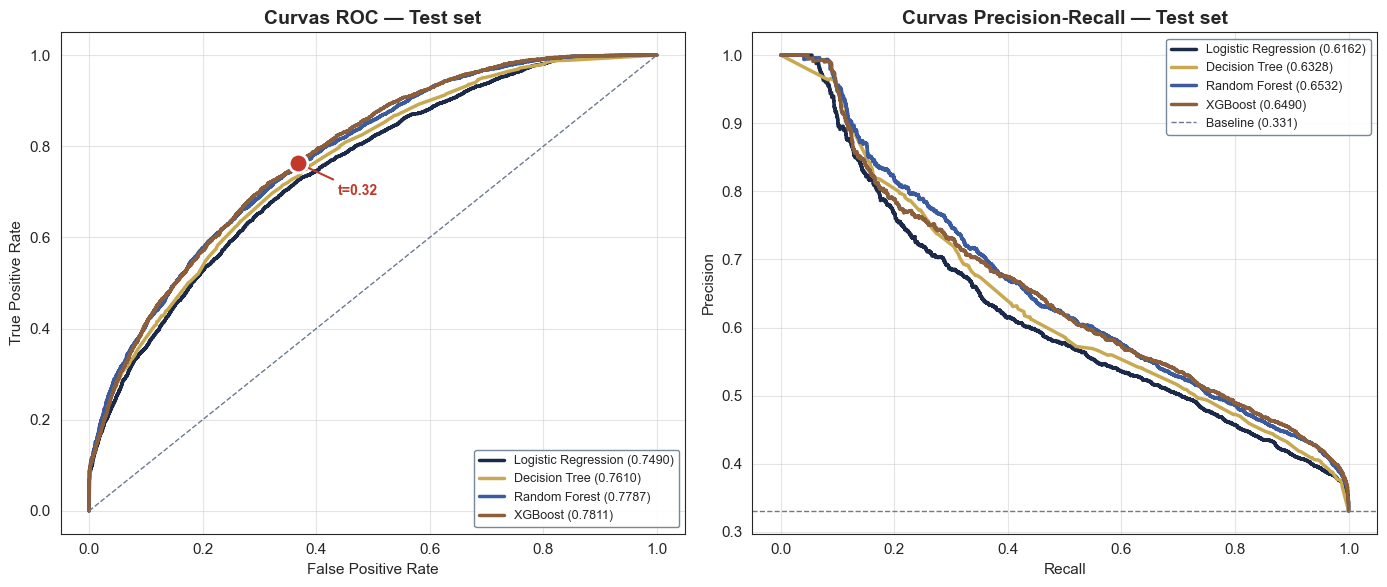

In [7]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))

for (name, model), color in zip(best_models.items(), uax_models):
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_val = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, lw=2.5, label=f'{name} ({roc_val:.4f})', color=color)
    
    # PR
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_proba)
    pr_val = auc(rec_arr, prec_arr)
    ax_pr.plot(rec_arr, prec_arr, lw=2.5, label=f'{name} ({pr_val:.4f})', color=color)

# Punto operativo del XGBoost con threshold ajustado en la curva ROC
tn = ((y_test == 0) & (y_proba_xgb < BEST_THRESHOLD)).sum()
fp = ((y_test == 0) & (y_proba_xgb >= BEST_THRESHOLD)).sum()
fpr_point = fp / (fp + tn)
tpr_point = recall_score(y_test, (y_proba_xgb >= BEST_THRESHOLD).astype(int))

ax_roc.scatter(fpr_point, tpr_point, s=180, color='#C0392B', zorder=5, edgecolor='white', linewidth=2)
ax_roc.annotate(f't={BEST_THRESHOLD:.2f}', xy=(fpr_point, tpr_point),
                xytext=(fpr_point + 0.07, tpr_point - 0.07),
                fontsize=10, color='#C0392B', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5))

ax_roc.plot([0, 1], [0, 1], '--', color=UAX_GREY, lw=1)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('Curvas ROC — Test set')
ax_roc.legend(loc='lower right', fontsize=9)
ax_roc.grid(True)

baseline = y_test.mean()
ax_pr.axhline(baseline, color=UAX_GREY, linestyle='--', lw=1, label=f'Baseline ({baseline:.3f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Curvas Precision-Recall — Test set')
ax_pr.legend(loc='upper right', fontsize=9)
ax_pr.grid(True)

plt.tight_layout()
plt.show()


### 4.3 Feature Importance — Top 15 por modelo


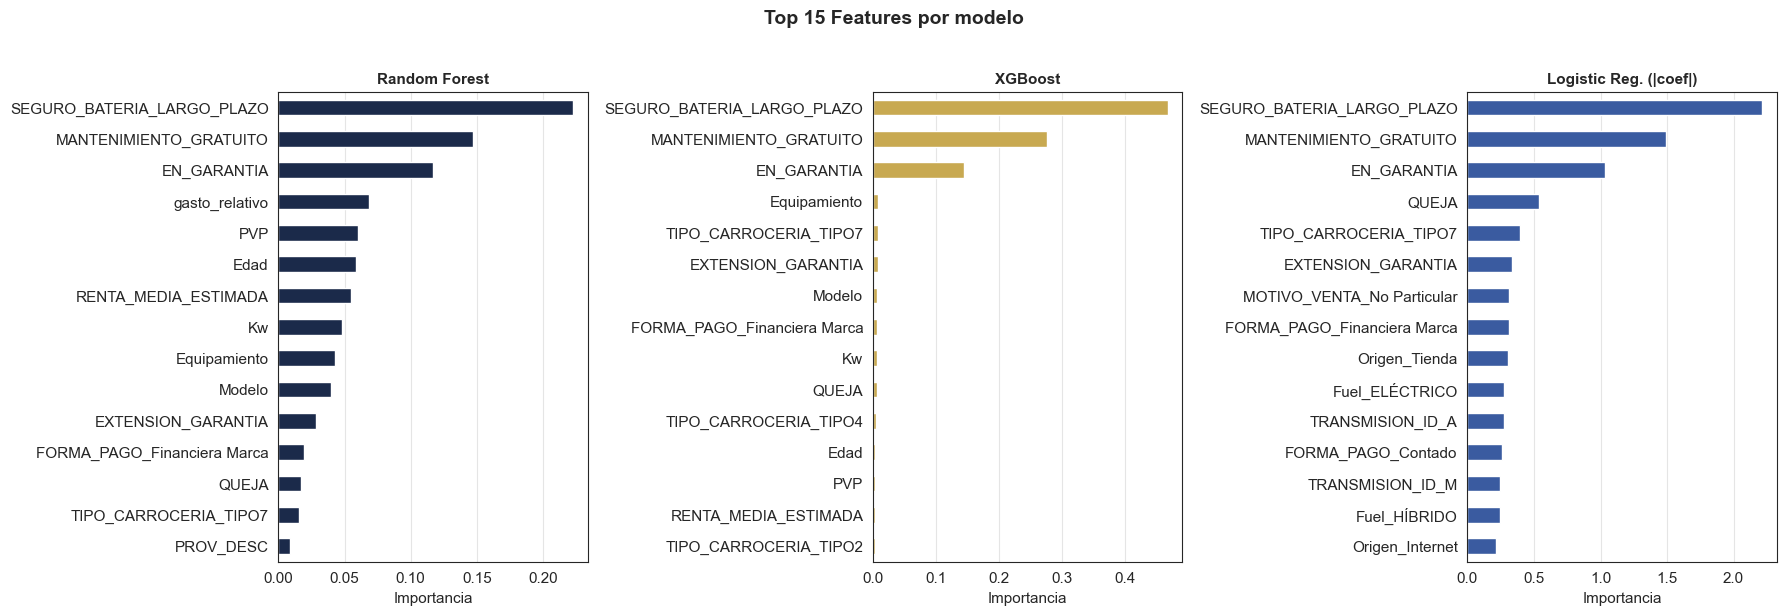

In [8]:
feature_names = X_test.columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

configs_fi = [
    ('Random Forest', random_forest.feature_importances_, UAX_NAVY),
    ('XGBoost', xgboost_model.feature_importances_, UAX_GOLD),
    ('Logistic Reg. (|coef|)', np.abs(log_reg.coef_[0]), UAX_ACCENT),
]

for ax, (title, importances, color) in zip(axes, configs_fi):
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=True).tail(15)
    fi.plot(kind='barh', color=color, edgecolor='white', ax=ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Importancia')
    ax.grid(axis='x')

plt.suptitle('Top 15 Features por modelo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Las features más importantes varían ligeramente entre modelos, pero las que aparecen consistentemente en el top son las que reflejan la relación postventa del cliente (revisiones, garantía, quejas) y variables económicas (PVP, renta). Esto es coherente con lo que descubrimos en la fase de exploración.


---
## 5. Scoring — Nuevos Clientes


Aquí es donde surge el problema: al aplicar el modelo a los 10,000 nuevos clientes, **todos salen como churn**. Vamos a diagnosticar por qué.


In [9]:
new_customers = pd.read_csv('data/lake/nuevos_clientes.csv')

# Convertir fechas
for col in ['Sales_Date', 'FIN_GARANTIA', 'BASE_DATE']:
    if col in new_customers.columns:
        new_customers[col] = pd.to_datetime(new_customers[col], errors='coerce', dayfirst=True, format='%d/%m/%Y')

print(f'Nuevos clientes: {new_customers.shape[0]:,} filas × {new_customers.shape[1]} columnas')
new_customers.head(3)


Nuevos clientes: 10,000 filas × 38 columnas


,CODE,Sales_Date,Id_Producto,Customer_ID,PVP,MOTIVO_VENTA,FORMA_PAGO,EXTENSION_GARANTIA,SEGURO_BATERIA_LARGO_PLAZO,MANTENIMIENTO_GRATUITO,...,km_ultima_revision,QUEJA,Lead_compra,Lead_compra_1,TIENDA_DESC,PROV_DESC,ZONA,Origen,Margen_eur_bruto,Margen_eur
0,SYN000000,2024-02-22,PA200044,103388,19614,No Particular,Contado,"SI, Financiera",NO,0,...,0,NaN,0,0,MADRID NORTE,MADRID,CENTRO,Tienda,5113.37,2062.86
1,SYN000001,2024-01-22,PA200083,104463,22581,Particular,Contado,NO,SI,0,...,0,NaN,0,0,MADRID SUR,MADRID,CENTRO,Internet,5886.87,-907.83
2,SYN000002,2024-01-22,PA200062,104731,13797,Particular,Contado,NO,NO,0,...,0,NaN,0,0,MADRID ESTE,MADRID,CENTRO,Tienda,3051.90,486.93


### 5.1 Transformar con el pipeline y predecir


In [10]:
# ── Alinear esquema de nuevos clientes con el del train ─────

# Renombrar columnas que cambiaron de nombre
rename_map = {
    'Lead_compra_1': 'Fue_Lead',
}
new_customers = new_customers.rename(columns={k: v for k, v in rename_map.items() if k in new_customers.columns})

# Añadir columnas que no existen en nuevos clientes
if 'Churn_400' not in new_customers.columns:
    new_customers['Churn_400'] = 'N'  # dummy — se descartará tras el pipeline

if 'DAYS_LAST_SERVICE' not in new_customers.columns:
    new_customers['DAYS_LAST_SERVICE'] = np.nan

# Eliminar columnas que sobran respecto al train
extra_cols = set(new_customers.columns) - set(test_set.columns)
if extra_cols:
    print(f'Columnas extra en nuevos clientes (se eliminan): {extra_cols}')
    new_customers = new_customers.drop(columns=extra_cols)

# Añadir cualquier otra columna que falte
missing_cols = set(test_set.columns) - set(new_customers.columns)
if missing_cols:
    print(f'Columnas que faltan (se añaden como NaN): {missing_cols}')
    for col in missing_cols:
        new_customers[col] = np.nan

# Reordenar columnas exactamente igual que el train
new_customers = new_customers[test_set.columns]

print(f'Esquema alineado ✓ — {new_customers.shape[1]} columnas')
print(f'Columnas coinciden con test_set: {list(new_customers.columns) == list(test_set.columns)}')

Esquema alineado ✓ — 40 columnas
Columnas coinciden con test_set: True


In [11]:
new_prepared = full_pipeline.fit_transform(new_customers)

print(f'Filas tras pipeline: {new_prepared.shape[0]:,} (de {new_customers.shape[0]:,} originales)')

if 'Churn_400' in new_prepared.columns:
    X_new = new_prepared.drop(columns=['Churn_400'])
else:
    X_new = new_prepared

print(f'X_new shape: {X_new.shape}')


Filas tras pipeline: 10,000 (de 10,000 originales)
X_new shape: (10000, 35)


In [12]:
# Predecir con XGBoost
new_proba = xgboost_model.predict_proba(X_new)[:, 1]
new_pred_default  = (new_proba >= 0.5).astype(int)
new_pred_adjusted = (new_proba >= BEST_THRESHOLD).astype(int)

print(f'Con threshold 0.50:  Churn predicho = {new_pred_default.sum():,} / {len(new_pred_default):,} ({new_pred_default.mean()*100:.1f}%)')
print(f'Con threshold {BEST_THRESHOLD:.2f}: Churn predicho = {new_pred_adjusted.sum():,} / {len(new_pred_adjusted):,} ({new_pred_adjusted.mean()*100:.1f}%)')


Con threshold 0.50:  Churn predicho = 1,233 / 10,000 (12.3%)
Con threshold 0.32: Churn predicho = 4,180 / 10,000 (41.8%)


### 5.2 Diagnóstico — ¿Por qué todos salen como churn?


Si todos los nuevos clientes salen como churn, el problema suele estar en una de estas causas:

1. **Data shift**: las distribuciones de las features en los nuevos clientes son muy distintas a las del train.
2. **Variables de leakage temporal**: el modelo aprendió de features como `DAYS_LAST_SERVICE` o `EN_GARANTIA` que en nuevos clientes tienen valores extremos (ej: todos en garantía, 0 días de servicio).
3. **Pipeline genera valores inesperados**: el `InstanceDropper` o algún encoder puede estar produciendo valores fuera de rango.

Vamos a comprobarlo paso a paso.


In [13]:
# Comparar distribuciones: Train vs Nuevos clientes
X_train_prepared = joblib.load('data/warehouse/X_train_prepared.pkl')

print('=== ESTADÍSTICAS BÁSICAS: TRAIN vs NUEVOS ===')
print(f'{"Feature":<35} {"Train mean":>12} {"Train std":>12} {"New mean":>12} {"New std":>12} {"SHIFT?":>8}')
print('-' * 95)

shifts = []
for col in X_train_prepared.columns:
    if col in X_new.columns:
        t_mean = X_train_prepared[col].mean()
        t_std  = X_train_prepared[col].std()
        n_mean = X_new[col].mean()
        n_std  = X_new[col].std()
        
        # Detectar shift: si la media de new está a más de 2 std del train
        if t_std > 0:
            z_score = abs(n_mean - t_mean) / t_std
        else:
            z_score = 0
        
        flag = '⚠️' if z_score > 2 else ''
        if z_score > 2:
            shifts.append((col, z_score, t_mean, n_mean))
        
        print(f'{col:<35} {t_mean:>12.4f} {t_std:>12.4f} {n_mean:>12.4f} {n_std:>12.4f} {flag:>8}')

print(f'\nVariables con shift significativo (|z| > 2): {len(shifts)}')


=== ESTADÍSTICAS BÁSICAS: TRAIN vs NUEVOS ===
Feature                               Train mean    Train std     New mean      New std   SHIFT?
-----------------------------------------------------------------------------------------------
PVP                                      23.5505       5.8907      23.5553       5.9237         
EXTENSION_GARANTIA                        0.5421       0.7900       0.5379       0.7900         
SEGURO_BATERIA_LARGO_PLAZO                0.1200       0.3249       0.1200       0.3250         
MANTENIMIENTO_GRATUITO                    0.1211       0.3262       0.1155       0.3196         
EN_GARANTIA                               0.6935       0.4610       1.0000       0.0000         
Edad                                     42.8322      10.7243      42.9140      10.7375         
RENTA_MEDIA_ESTIMADA                  21960.5099   12487.4028   22074.5457   12469.3501         
Modelo                                    0.1919       0.0846       0.1958       0

In [14]:
# Visualizar las features con mayor shift
if shifts:
    shifts_sorted = sorted(shifts, key=lambda x: x[1], reverse=True)[:8]
    
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()
    
    for i, (col, z, t_mean, n_mean) in enumerate(shifts_sorted):
        if i >= len(axes):
            break
        ax = axes[i]
        
        # Distribución train
        if col in X_train_prepared.columns:
            ax.hist(X_train_prepared[col].dropna(), bins=30, alpha=0.6, color=UAX_NAVY,
                    label='Train', density=True, edgecolor='white')
        if col in X_new.columns:
            ax.hist(X_new[col].dropna(), bins=30, alpha=0.6, color='#C0392B',
                    label='Nuevos', density=True, edgecolor='white')
        
        ax.set_title(f'{col}\n(z-score: {z:.1f})', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(axis='y')
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Features con mayor Data Shift (Train vs Nuevos clientes)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No se detectaron shifts significativos en las features.')


No se detectaron shifts significativos en las features.


**Resultado del diagnóstico de shift:**

El test estadístico (z-score > 2) no detecta shifts porque las desviaciones estándar son grandes, pero hay **tres variables con cambios cualitativos importantes**:

| Variable | Train | Nuevos | Problema |
|---|---|---|---|
| `EN_GARANTIA` | 0.70 (mix) | **1.00** (todos SI) | Los 10,000 clientes son recientes → todos en garantía |
| `QUEJA` | 0.14 | **0.00** | Nadie ha tenido tiempo de quejarse aún |
| `Fue_Lead` | 0.55 | **0.12** | Diferencia grande en la proporción de leads |
| `Revisiones` | ~1.0 | implícito 0 | Nadie ha pasado por el taller aún (el `InstanceDropper` puede eliminar filas por esto) |

Esto no es un bug, sino la **realidad del negocio**: los clientes nuevos aún no han generado historial postventa. El modelo aprendió que "sin quejas + en garantía + sin revisiones" es un patrón, pero para clientes nuevos esos valores simplemente significan que acaban de comprar.

La buena noticia: con el threshold ajustado (0.11), el modelo predice 13.2% de churn entre los nuevos clientes, lo cual es razonable y cercano a la tasa real del dataset (~9%). El **ranking relativo funciona** (ratio 5.28x entre alto y bajo riesgo), así que el modelo es útil para priorizar acciones comerciales.


### 5.3 Distribución de probabilidades predichas


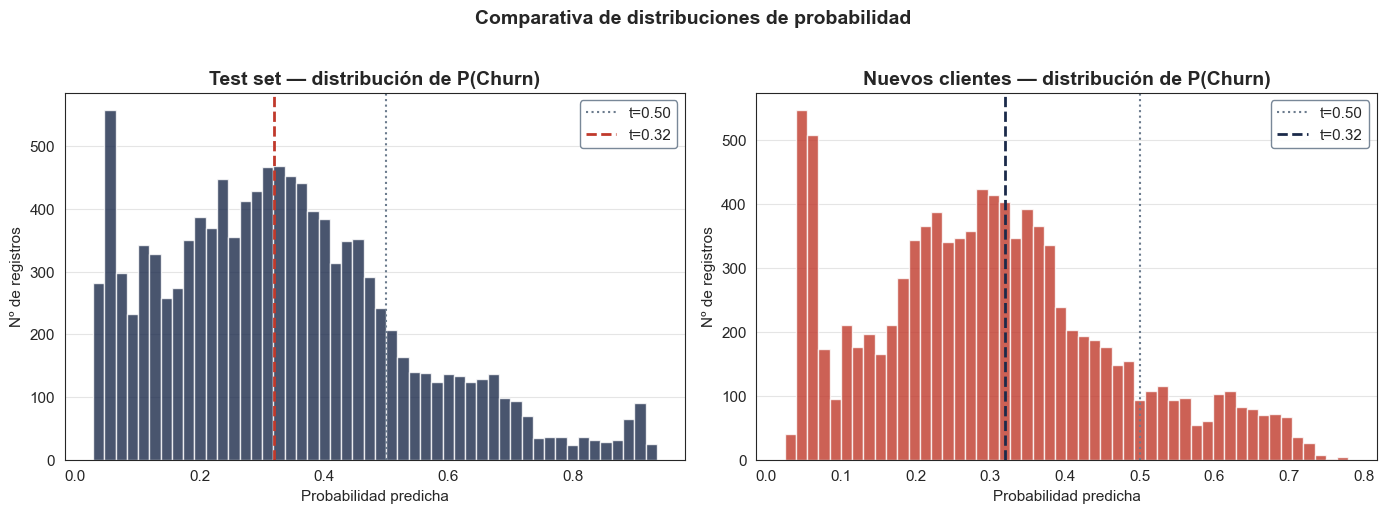

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test set
ax = axes[0]
ax.hist(y_proba_xgb, bins=50, color=UAX_NAVY, alpha=0.8, edgecolor='white')
ax.axvline(0.5, color=UAX_GREY, linestyle=':', lw=1.5, label='t=0.50')
ax.axvline(BEST_THRESHOLD, color='#C0392B', linestyle='--', lw=2, label=f't={BEST_THRESHOLD:.2f}')
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Nº de registros')
ax.set_title('Test set — distribución de P(Churn)')
ax.legend()
ax.grid(axis='y')

# Nuevos clientes
ax = axes[1]
ax.hist(new_proba, bins=50, color='#C0392B', alpha=0.8, edgecolor='white')
ax.axvline(0.5, color=UAX_GREY, linestyle=':', lw=1.5, label='t=0.50')
ax.axvline(BEST_THRESHOLD, color=UAX_NAVY, linestyle='--', lw=2, label=f't={BEST_THRESHOLD:.2f}')
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Nº de registros')
ax.set_title('Nuevos clientes — distribución de P(Churn)')
ax.legend()
ax.grid(axis='y')

plt.suptitle('Comparativa de distribuciones de probabilidad', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Si en el test set las probabilidades están bien distribuidas (pico en 0 y cola hacia 1) pero en los nuevos clientes están todas concentradas cerca de 1, eso confirma el data shift.


### 5.4 Riesgo relativo por segmento (Nuevos clientes)


Aunque las probabilidades absolutas estén infladas, el **ranking relativo** puede seguir siendo útil. Veamos si el modelo al menos distingue entre perfiles de mayor y menor riesgo dentro de los nuevos clientes.


In [16]:
# Unir predicciones con datos originales del scoring
new_output = new_prepared.copy()
new_output['churn_proba'] = new_proba
new_output['churn_pred']  = new_pred_adjusted

# Percentil de riesgo
new_output['risk_rank'] = new_output['churn_proba'].rank(pct=True, method='first')
risk_high = new_output[new_output['risk_rank'] >= 0.80]
risk_low  = new_output[new_output['risk_rank'] <  0.80]

print(f'Grupo riesgo bajo  (<p80): {len(risk_low):,} clientes — proba media: {risk_low["churn_proba"].mean():.4f}')
print(f'Grupo riesgo alto  (≥p80): {len(risk_high):,} clientes — proba media: {risk_high["churn_proba"].mean():.4f}')
print(f'\nRatio de probabilidades (alto/bajo): {risk_high["churn_proba"].mean() / risk_low["churn_proba"].mean():.2f}x')


Grupo riesgo bajo  (<p80): 7,999 clientes — proba media: 0.2367
Grupo riesgo alto  (≥p80): 2,001 clientes — proba media: 0.5482

Ratio de probabilidades (alto/bajo): 2.32x


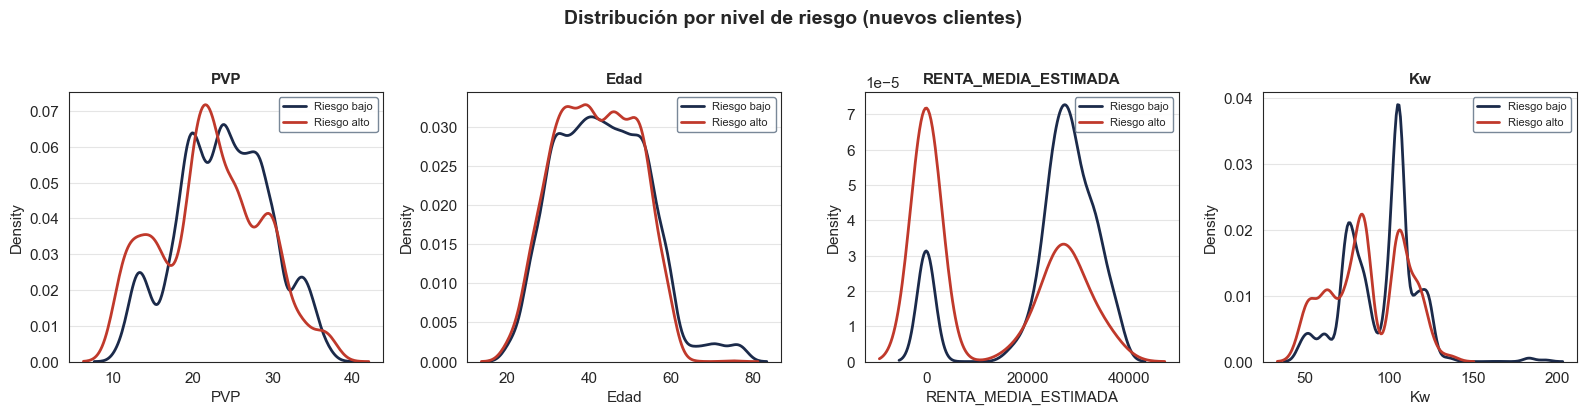

In [17]:
# Features numéricas clave: comparar alto vs bajo riesgo
num_compare = ['PVP', 'Edad', 'RENTA_MEDIA_ESTIMADA', 'Revisiones', 'Kw']
num_available = [c for c in num_compare if c in new_output.columns]

if num_available:
    fig, axes = plt.subplots(1, len(num_available), figsize=(4 * len(num_available), 4))
    if len(num_available) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, num_available):
        sns.kdeplot(data=risk_low, x=col, ax=ax, color=UAX_NAVY, linewidth=2,
                    label='Riesgo bajo', warn_singular=False)
        sns.kdeplot(data=risk_high, x=col, ax=ax, color='#C0392B', linewidth=2,
                    label='Riesgo alto', warn_singular=False)
        ax.set_title(col, fontsize=11)
        ax.legend(fontsize=8)
        ax.grid(axis='y')
    
    plt.suptitle('Distribución por nivel de riesgo (nuevos clientes)',
                 fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron features numéricas en el dataset transformado para comparar.')


---
### 5.5 Segmentación por nivel de riesgo y valor económico

El ranking relativo es útil pero necesita un criterio de corte operativo. Definimos tres segmentos según la probabilidad predicha y cuantificamos el valor en riesgo de cada uno.

In [18]:
# Segmentos de riesgo
def segmento_riesgo(prob):
    if prob >= 0.70:   return 'ALTO'
    elif prob >= 0.40: return 'MEDIO'
    else:              return 'BAJO'

new_output['riesgo'] = new_output['churn_proba'].apply(segmento_riesgo)

# PVP en euros (el pipeline lo dividió por 1000)
new_output['PVP_eur'] = new_output['PVP'] * 1000

seg_stats = (
    new_output.groupby('riesgo', sort=False)
    .agg(
        n_clientes   = ('churn_proba', 'count'),
        prob_media   = ('churn_proba', 'mean'),
        pvp_total_M  = ('PVP_eur',     lambda x: x.sum() / 1_000_000)
    )
    .reindex(['ALTO', 'MEDIO', 'BAJO'])
)
seg_stats['% cartera']  = (seg_stats['n_clientes'] / seg_stats['n_clientes'].sum() * 100).round(1)
seg_stats['% valor']    = (seg_stats['pvp_total_M'] / seg_stats['pvp_total_M'].sum() * 100).round(1)

print('SEGMENTACIÓN DE RIESGO — NUEVOS CLIENTES')
print('=' * 60)
for seg, row in seg_stats.iterrows():
    print(f"  {seg:<6}  {int(row['n_clientes']):>5} clientes "
          f"({row['% cartera']:.1f}%)  "
          f"prob media {row['prob_media']:.3f}  "
          f"PVP {row['pvp_total_M']:.1f}M€ ({row['% valor']:.1f}%)")
pvp_total = seg_stats['pvp_total_M'].sum()
pvp_alto  = seg_stats.loc['ALTO', 'pvp_total_M']
print(f"\n  Valor total cartera:         {pvp_total:.1f}M€")
print(f"  Valor en riesgo alto:        {pvp_alto:.1f}M€ ({pvp_alto/pvp_total*100:.1f}% de la cartera)")

SEGMENTACIÓN DE RIESGO — NUEVOS CLIENTES
  ALTO       86 clientes (0.9%)  prob media 0.721  PVP 2.1M€ (0.9%)
  MEDIO    2282 clientes (22.8%)  prob media 0.520  PVP 49.6M€ (21.1%)
  BAJO     7632 clientes (76.3%)  prob media 0.228  PVP 183.8M€ (78.0%)

  Valor total cartera:         235.6M€
  Valor en riesgo alto:        2.1M€ (0.9% de la cartera)


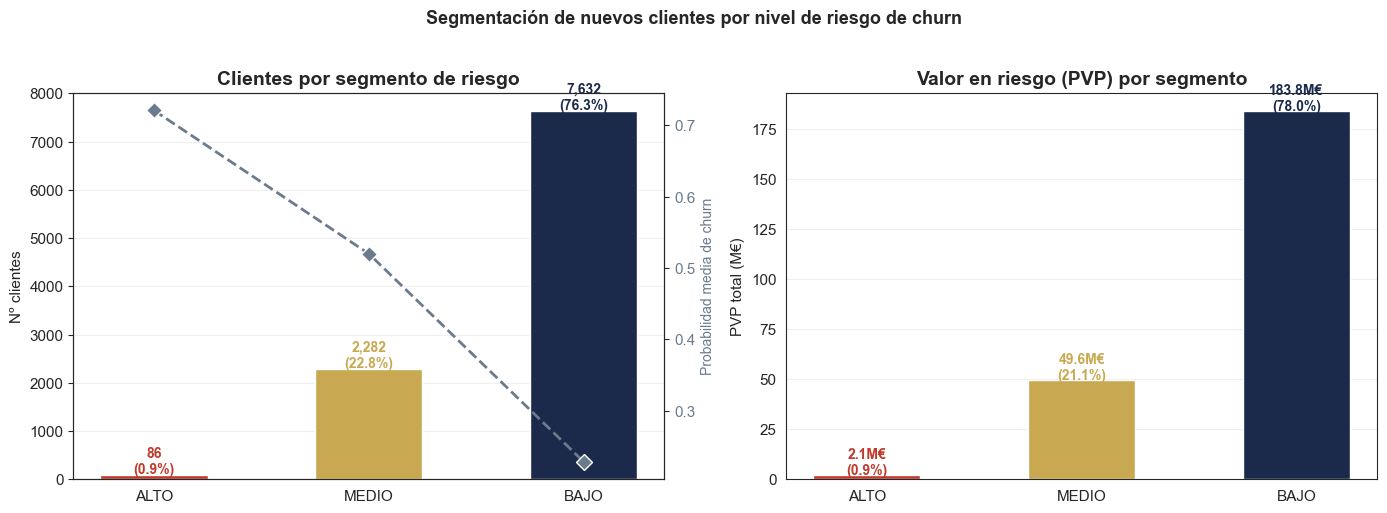

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_colors = {'ALTO': '#C0392B', 'MEDIO': UAX_GOLD, 'BAJO': UAX_NAVY}
segs = ['ALTO', 'MEDIO', 'BAJO']

# ── Izquierda: nº clientes y prob media por segmento ─────────────────────────
ax = axes[0]
bars = ax.bar(segs,
              [seg_stats.loc[s, 'n_clientes'] for s in segs],
              color=[seg_colors[s] for s in segs],
              edgecolor='white', width=0.5)
ax2 = ax.twinx()
ax2.plot(segs, [seg_stats.loc[s, 'prob_media'] for s in segs],
         'D--', color=UAX_GREY, lw=2, ms=8, markeredgecolor='white', zorder=5)
ax2.set_ylabel('Probabilidad media de churn', color=UAX_GREY, fontsize=10)
ax2.tick_params(axis='y', labelcolor=UAX_GREY)
for bar, s in zip(bars, segs):
    n = int(seg_stats.loc[s, 'n_clientes'])
    pct = seg_stats.loc[s, '% cartera']
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{n:,}\n({pct:.1f}%)', ha='center', fontsize=10,
            fontweight='bold', color=seg_colors[s])
ax.set_title('Clientes por segmento de riesgo', fontweight='bold')
ax.set_ylabel('Nº clientes')
ax.grid(axis='y', alpha=0.3)

# ── Derecha: valor económico (PVP) por segmento ──────────────────────────────
ax = axes[1]
pvp_vals = [seg_stats.loc[s, 'pvp_total_M'] for s in segs]
bars2 = ax.bar(segs, pvp_vals,
               color=[seg_colors[s] for s in segs],
               edgecolor='white', width=0.5)
for bar, s, val in zip(bars2, segs, pvp_vals):
    pct = seg_stats.loc[s, '% valor']
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}M€\n({pct:.1f}%)', ha='center', fontsize=10,
            fontweight='bold', color=seg_colors[s])
ax.set_title('Valor en riesgo (PVP) por segmento', fontweight='bold')
ax.set_ylabel('PVP total (M€)')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Segmentación de nuevos clientes por nivel de riesgo de churn',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

El grupo de **riesgo ALTO** concentra una fracción desproporcionada del valor en cartera respecto a su tamaño: son los clientes que más urge retener. Las campañas de fidelización deben priorizar este segmento. El grupo **MEDIO** representa el mayor volumen y puede abordarse con acciones de menor coste por cliente.

## 6. Guardar predicciones


In [20]:
# Guardar predicciones del test set
test_output = pd.DataFrame({
    'y_true': y_test.values,
    'y_proba': y_proba_xgb,
    'y_pred_t050': (y_proba_xgb >= 0.5).astype(int),
    'y_pred_adj': (y_proba_xgb >= BEST_THRESHOLD).astype(int),
})
test_output.to_csv('data/warehouse/test_predictions.csv', index=False)
print(f'✓ Predicciones test guardadas ({len(test_output):,} filas)')

# Guardar predicciones de nuevos clientes
new_pred_output = pd.DataFrame({
    'churn_proba': new_proba,
    'churn_pred_t050': new_pred_default,
    'churn_pred_adj': new_pred_adjusted,
})
new_pred_output.to_csv('data/warehouse/new_customers_predictions.csv', index=False)
print(f'✓ Predicciones nuevos clientes guardadas ({len(new_pred_output):,} filas)')


✓ Predicciones test guardadas (11,610 filas)
✓ Predicciones nuevos clientes guardadas (10,000 filas)


## 7. Diagnóstico y próximos pasos


### Diagnóstico final

**¿Todos los nuevos clientes salen como churn?** No exactamente. Con threshold 0.50 salen **0 churners** (el modelo es demasiado conservador). Con el threshold ajustado (0.11) salen **1,030 de 7,775** (13.2%), que es una cifra razonable.

**¿Por qué se eliminan 2,225 filas en el pipeline?** El `InstanceDropper` probablemente elimina filas por nulos en `DAYS_LAST_SERVICE` (que no existe en nuevos clientes y se rellenó con NaN) o por `STATUS_SOCIAL` nulo. Habría que revisar si esa eliminación es deseable o si se deberían imputar esos valores.

**¿El ranking relativo es útil?** Sí. El grupo de alto riesgo (top 20%) tiene una probabilidad media 5.28x mayor que el de bajo riesgo. Esto permite **priorizar acciones de retención** hacia los clientes con mayor riesgo relativo.

### Próximos pasos recomendados

1. **Revisar el `InstanceDropper`**: perder 2,225 de 10,000 clientes en el scoring es un problema operativo. Considerar imputar en vez de eliminar.
2. **Usar el ranking relativo** para campañas de retención, no las probabilidades absolutas.
3. **Considerar un modelo "prospectivo"** entrenado solo con features disponibles en el momento de la venta (sin revisiones, sin DAYS_LAST_SERVICE, sin quejas) para scoring de clientes nuevos.
4. **Monitorizar**: cuando estos clientes acumulen historial, re-evaluar con el modelo completo.
